# Train a Model with DP-SGD

This notebook trains a logistic regression model on synthetic data using
differentially private stochastic gradient descent (DP-SGD). It covers
the core Opaque workflow: functional model conversion, per-example
gradient clipping, noise injection, and privacy accounting.

**Prerequisites:** Basic PyTorch (tensors, `torch.nn`, optimizers).

**Components exercised:**
`make_functional`, `clipped_grad`, `gaussian_noise`, `opaque.accounting`,
`acc.calibrate`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import opaque.accounting as acc
import opaque.dpsgd.accounting as dpsgd_acc
from opaque.dpsgd.clipping import clipped_grad
from opaque.dpsgd.noise import gaussian_noise
from opaque.dpsgd.sampling import PoissonSampler
from opaque.functional import make_functional
from opaque.random import key

torch.manual_seed(42)
np.random.seed(42)

## Synthetic data

A binary classification task with 10 features and 2000 examples.

In [2]:
n_samples, n_features = 2000, 10
X = torch.randn(n_samples, n_features)
y = (X[:, 0] + 0.5 * X[:, 1] > 0).float()

print(f"Dataset: {n_samples} samples, {n_features} features")
print(f"Positive class: {y.mean():.1%}")

Dataset: 2000 samples, 10 features
Positive class: 51.0%


## Functional model conversion

DP-SGD requires per-example gradients, which `torch.func.vmap` computes
efficiently. This requires a *functional* model where parameters are
passed explicitly. `make_functional` handles the conversion.

In [3]:
model = nn.Linear(n_features, 1)
fmodel, params = make_functional(model)

for i, p in enumerate(params):
    print(f"params[{i}]: {p.shape}")

params[0]: torch.Size([1, 10])
params[1]: torch.Size([1])


## Per-example loss function

The loss function must accept a **single example**, not a batch.
`clipped_grad` uses `vmap` internally to vectorise across the batch
dimension.

In [4]:
def loss_fn(params, x, y):
    logit = fmodel(params, x.unsqueeze(0)).squeeze()
    return F.binary_cross_entropy_with_logits(logit, y)

## Privacy parameters and calibration

We fix a privacy target (ε, δ) and use `acc.calibrate` to
find the noise multiplier that achieves it over the planned number of
training steps.

In [5]:
target_epsilon = 3.0
target_delta = 1e-5
batch_size = 64
n_epochs = 20
sample_rate = batch_size / n_samples
steps_per_epoch = n_samples // batch_size
total_steps = n_epochs * steps_per_epoch

result = acc.calibrate(
    acc.epsilon_budget(target_epsilon, delta=target_delta),
    lambda nm: dpsgd_acc.poisson(dpsgd_acc.gaussian(nm), sample_rate) * total_steps,
    param_min=0.1,
    param_max=100.0,
)
noise_multiplier = result.param
print(f"Calibrated noise multiplier: {noise_multiplier:.4f}")

Calibrated noise multiplier: 1.3569


## Clipped gradient function

`clipped_grad` wraps the loss function and returns a gradient function
that computes per-example gradients, clips each to a fixed L2 norm,
and sums the result.

In [6]:
clipping_norm = 1.0

dp_grad_fn, clip_state = clipped_grad(
    loss_fn,
    argnums=0,  # differentiate w.r.t. params
    batch_argnums=(1, 2),  # x and y are batched
    clipping_norm=clipping_norm,
    normalize_by=batch_size,
)

# `gaussian_noise` reads per-step sensitivity from each ClippedPytree input.
noise_fn, noise_state = gaussian_noise(
    noise_multiplier=noise_multiplier,
    key=key(42),
)

print(f"Clip norm: {clipping_norm}")
print(f"Per-record sensitivity: {clipping_norm / batch_size:.4f}")
print(f"Noise multiplier: {noise_multiplier:.4f}")

Clip norm: 1.0
Per-record sensitivity: 0.0156
Noise multiplier: 1.3569


## Training loop

The DP-SGD loop differs from standard SGD in two lines:
1. `dp_grad_fn` replaces the standard gradient call (clips per-example).
2. `noise_fn` adds calibrated Gaussian noise to the clipped sum.

Everything else is identical.

In [7]:
lr = 0.1
losses = []
epsilons = []
dataset = TensorDataset(X, y)
sampler = PoissonSampler(
    dataset, sample_rate=sample_rate, n_steps=total_steps, key=key(43),
)
loader = DataLoader(dataset, batch_sampler=sampler)
epoch_loss = 0.0

for step, (xb, yb) in enumerate(loader, start=1):
    # The sampler and accountant use the same independent-inclusion process.
    grads, clip_state = dp_grad_fn(params, xb, yb, state=clip_state)
    noisy_grads, noise_state = noise_fn(grads, noise_state)

    # Gradients are already normalized by the fixed expected batch size.
    params = tuple(p - lr * g for p, g in zip(params, noisy_grads.pytree))

    with torch.no_grad():
        epoch_loss += loss_fn(params, xb, yb).item()

    if step % steps_per_epoch == 0:
        epoch = step // steps_per_epoch
        process = (
            dpsgd_acc.poisson(dpsgd_acc.gaussian(noise_multiplier), sample_rate) * step
        )
        eps = process.epsilon_at(target_delta)
        avg_loss = epoch_loss / steps_per_epoch
        epoch_loss = 0.0
        losses.append(avg_loss)
        epsilons.append(eps)

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:2d}/{n_epochs}  loss={avg_loss:.4f}  epsilon={eps:.2f}"
            )

print(f"\nFinal privacy: (epsilon={epsilons[-1]:.2f}, delta={target_delta})")

Epoch  1/20  loss=0.6199  epsilon=0.75


Epoch  5/20  loss=0.2646  epsilon=1.50


Epoch 10/20  loss=0.1885  epsilon=2.10


Epoch 15/20  loss=0.1601  epsilon=2.58


Epoch 20/20  loss=0.1501  epsilon=3.00

Final privacy: (epsilon=3.00, delta=1e-05)


## Results

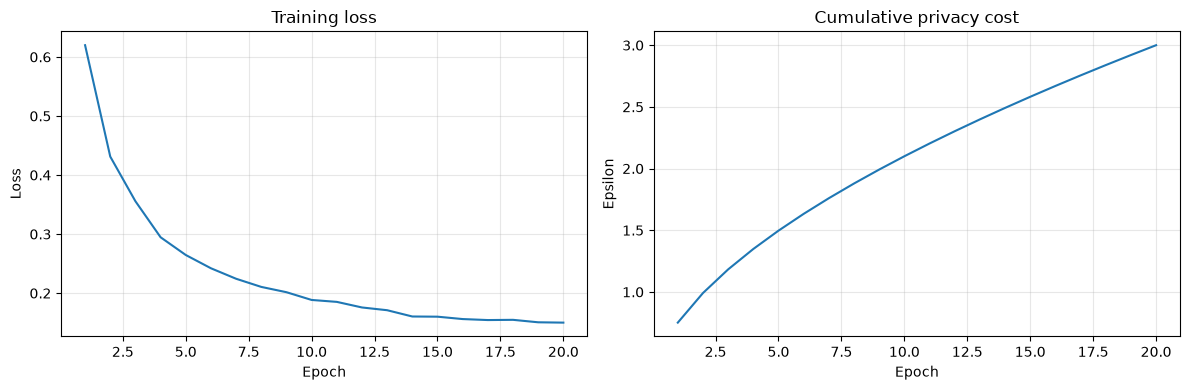

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, n_epochs + 1), losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training loss")
ax1.grid(alpha=0.3)

ax2.plot(range(1, n_epochs + 1), epsilons)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Epsilon")
ax2.set_title("Cumulative privacy cost")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluating on held-out data

In [9]:
X_test = torch.randn(500, n_features)
y_test = (X_test[:, 0] + 0.5 * X_test[:, 1] > 0).float()

with torch.no_grad():
    logits = fmodel(params, X_test).squeeze()
    preds = (logits > 0).float()
    accuracy = (preds == y_test).float().mean()

print(f"Test accuracy: {accuracy:.1%}")

Test accuracy: 99.0%


## Summary

The complete DP-SGD workflow in Opaque:

1. Convert the model with `make_functional`.
2. Write a per-example loss function.
3. Calibrate the noise multiplier with `acc.calibrate`.
4. Create `clipped_grad` and `gaussian_noise` functions.
5. Train with the standard loop, replacing the gradient call.

For adaptive clipping, sampling strategies, and LLM fine-tuning,
see the other tutorials.